<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_222_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

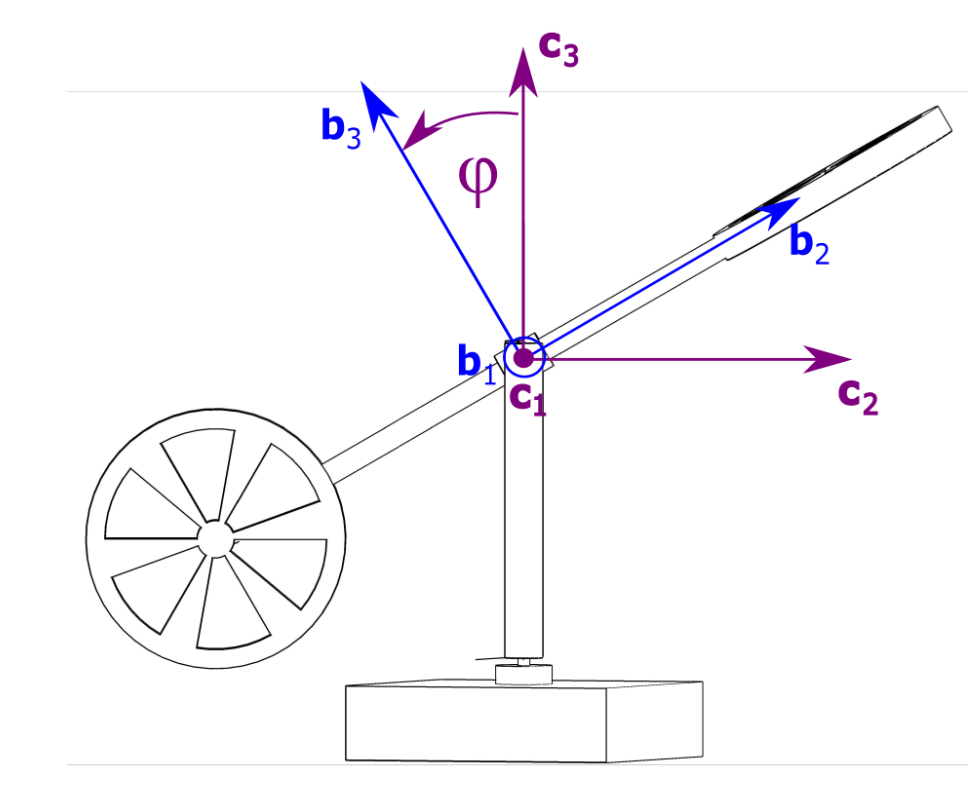

 ## Task 1 — Dynamic Model of the Twin Rotor System


# 1. Configuration Space

The twin–rotor mechanism performs rotational motion about a fixed pivot point.
Therefore the configuration of the system belongs to the Lie group

$$R(t) \in SO(3)$$

To describe the orientation, two rotations are used:

1. A rotation of angle $\theta$ about the inertial axis $e_3$
2. A rotation of angle $\phi$ about the intermediate body axis $b_1$

Hence the overall rotation matrix can be written as

$$R = R_1(\phi) R_3(\theta)$$

where

$$R_1(\phi) =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}$$

and

$$R_3(\theta) =
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{bmatrix}$$

---

# 2. Angular Velocity and Kinematics on $SO(3)$

For a rigid body whose orientation evolves on the manifold $SO(3)$, the kinematic relation is

$$\dot{R} = R \hat{\Omega}$$

where $\Omega$ denotes the angular velocity expressed in body coordinates and

$$\hat{\Omega} =
\begin{bmatrix}
0 & -\Omega_3 & \Omega_2 \\
\Omega_3 & 0 & -\Omega_1 \\
-\Omega_2 & \Omega_1 & 0
\end{bmatrix}$$

From the chosen rotation sequence, the body angular velocity becomes

$$\Omega =
\begin{bmatrix}
\dot{\phi} \\
\dot{\theta}\sin\phi \\
\dot{\theta}\cos\phi
\end{bmatrix}$$

The spatial angular velocity is related to the body velocity through

$$\omega = R\Omega$$

Therefore the kinematic equation may also be written as

$$\dot{R} = \hat{\omega}R$$

---

# 3. Inertia and Angular Momentum

Assume that the inertia tensor of the body is diagonal:

$$I =
\begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}$$

The angular momentum expressed in spatial coordinates is

$$\pi = R I \Omega$$

Since the relation between spatial and body angular velocity is

$$\Omega = R^T \omega$$

the momentum can also be expressed as

$$\pi = R I R^T \omega$$

Consequently the angular velocity can be recovered from the momentum by

$$\omega = (R I R^T)^{-1}\pi$$

---

# 4. Rotational Dynamics

The rotational motion of the rigid body in spatial form is governed by

$$\dot{\pi} = \tau$$

where $\tau$ represents the total torque applied to the system.

This torque can be separated into two components

$$\tau = \tau^e + \tau^u$$

where

- $\tau^u$ represents the controllable torque produced by the rotors
- $\tau^e$ represents constraint forces imposed by the mechanical structure

Thus the momentum evolution equation becomes

$$\dot{\pi} = \tau^e + \tau^u$$

---

# 5. Control Torque

The thrust generated by the two rotors creates moments acting within the $b_1$–$b_3$ plane.

The control torque expressed in spatial coordinates can be written as

$$\tau^u =
R
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\beta \\
0 \\
u_1\sin\alpha - u_2\sin\beta
\end{bmatrix}$$

This torque has no component along the $b_2$ axis.

---

# 6. Constraint Torque

The system design restricts rotation around the $b_2$ direction.
To enforce this restriction, a constraint torque must appear along that axis.

The Euler equation for the rigid body in body coordinates is

$$I\dot{\Omega} + \Omega \times (I\Omega) = T$$

where $T$ denotes the torque in body coordinates.

Projecting this equation onto the $e_2$ direction gives

$$T_2 =
e_2^T(\Omega \times I\Omega + I\dot{\Omega})$$

Therefore the constraint torque expressed in spatial coordinates becomes

$$\tau^e =
R
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}$$

---

# 7. Final Dynamic Model

Combining the kinematic and dynamic relationships, the twin rotor system can be summarized by the following equations.

**Kinematics:**

$$\dot{R} = \hat{\omega}R$$

**Momentum dynamics:**

$$\dot{\pi} = \tau^e + \tau^u$$

**Velocity–momentum relation:**

$$\omega = (RIR^T)^{-1}\pi$$

**Control torque:**

$$\tau^u =
R
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\beta \\
0 \\
u_1\sin\alpha - u_2\sin\beta
\end{bmatrix}$$

**Constraint torque:**

$$\tau^e =
R
\begin{bmatrix}
0 \\
e_2^T(\Omega \times I\Omega + I\dot{\Omega}) \\
0
\end{bmatrix}$$

This formulation provides a geometric representation of the twin–rotor dynamics on the Lie group $SO(3)$.

**Relation Between $\Omega$ and $\omega$:**

$$\Omega = R^T \omega$$

## Task 2: Simulation of the Motion of the Twin Rotor System

In the body-fixed frame $\mathbf{b}$, the principal moments of inertia $I_1$, $I_2$, and $I_3$
correspond to rotations about the pitch, roll, and yaw axes, respectively.
Since the mechanical design of the experimental setup prevents rolling motion,
the inertia component $I_2$ has no effect on the dynamics and is therefore neglected.
Furthermore, the moment of inertia about the yaw axis exceeds that about the pitch axis,
satisfying $I_3 > I_1$. This inequality arises from the fact that yaw rotation involves
heavier structural elements — including the vertical support column — while pitch rotation
is governed primarily by the horizontal arm that connects the two rotor assemblies.

In [3]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

# ── Inertia tensor ──────────────────────────────────────────────
I1, I2, I3 = 1.0, 2.0, 1.5
I = np.diag([I1, I2, I3])

# ── Control input selector ──────────────────────────────────────
CASE = 4   # change to 1, 2, 3, or 4

def control_inputs(t):
    cases = {
        1: [0.5 * np.sin(2 * t), -0.2 * np.cos(t)],
        2: [1.0, 1.0],
        3: [1.0, 0.0],
        4: [0.0, 1.0],
    }
    return np.array(cases[CASE])

# ── Individual accessors ─────────────────────────────────────────
u1 = lambda t: control_inputs(t)[0]
u2 = lambda t: control_inputs(t)[1]

## Twin Rotor System — Dynamic Model Derivation

Working in the body-fixed frame, the following quantities are introduced:

$$
T_e =
\begin{bmatrix}
0 \\
T_{e_2} \\
0
\end{bmatrix}, \quad
\Omega =
\begin{bmatrix}
\Omega_1 \\
\Omega_2 \\
\Omega_3
\end{bmatrix}, \quad
I =
\begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}
$$

Applying Euler's rigid body equation yields the governing rotational dynamics:

$$
T_e + T_u = \Omega \times (I \Omega) + I \dot{\Omega}
$$

Substituting the explicit forms of the constraint and control torque vectors:

$$
\begin{bmatrix}
0 \\
T_{e_2} \\
0
\end{bmatrix}
+
\begin{bmatrix}
u_1 \\
0 \\
-u_2
\end{bmatrix}
=
\begin{bmatrix}
(I_3 - I_2)\Omega_2 \Omega_3 + I_1 \dot{\Omega}_1 \\
(I_1 - I_3)\Omega_1 \Omega_3 + I_2 \dot{\Omega}_2 \\
(I_2 - I_1)\Omega_1 \Omega_2 + I_3 \dot{\Omega}_3
\end{bmatrix}
$$

---

### Body Angular Velocity in Generalized Coordinates

Expressing the body angular velocity vector in terms of the generalized coordinates $\phi$ and $\theta$:

$$
\Omega =
\begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin\phi \\
\dot{\theta} \cos\phi
\end{bmatrix}
$$

Differentiating with respect to time:

$$
\dot{\Omega} =
\begin{bmatrix}
\ddot{\phi} \\
\ddot{\theta} \sin\phi + \dot{\theta}\dot{\phi}\cos\phi \\
\ddot{\theta} \cos\phi - \dot{\theta}\dot{\phi}\sin\phi
\end{bmatrix}
$$

---

### Row-wise Expansion of the Euler Equation

Matching each row on both sides of the Euler equation gives three scalar relations:

$$
u_1 = (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi + I_1 \ddot{\phi}
$$

$$
T_{e_2} = (I_1 - I_3)\dot{\phi}\dot{\theta}\cos\phi + I_2\left(\ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi\right)
$$

$$
-u_2 = (I_2 - I_1)\dot{\phi}\dot{\theta}\sin\phi + I_3\left(\ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi\right)
$$

The quantity $T_{e_2}$ captures the reaction torque acting at the pivot joint.

---

### Solved Equations of Motion

Rearranging the first and third scalar equations for the second-order derivatives:

$$
\ddot{\phi} =
\frac{1}{I_1}
\left[
u_1 - (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi
\right]
$$

$$
\ddot{\theta} =
\frac{1}{\cos\phi}
\left[
\frac{1}{I_3}
\left(
(I_1 - I_2)\dot{\phi}\dot{\theta}\sin\phi - u_2
\right)
+ \dot{\theta}\dot{\phi}\sin\phi
\right]
$$

---

### Kinematic Singularity

The equations of motion lose validity when:

$$
\phi = 90°
$$

At this configuration, $\cos\phi = 0$ causes the expression for $\ddot{\theta}$ to become undefined.
This breakdown is a kinematic singularity, commonly referred to as **gimbal lock**.

In [4]:
# ══════════════════════════════════════════════════════════════
#  Twin Rotor — Dynamics · Simulation · 3-D Animation
# ══════════════════════════════════════════════════════════════

# ─── Parameters ───────────────────────────────────────────────
L_VERT   = 2.0          # vertical support length
L_BEAM   = 3.0          # horizontal beam length
EPS      = 1e-5         # singularity guard threshold
T_SPAN   = (0, 10)
N_PTS    = 300
IC       = [0.1, 0.0, 0.0, 0.0]   # θ, φ, θ̇, φ̇


# ─── 1  Equations of motion ───────────────────────────────────

def twin_rotor_ode(t, state):
    th, ph, th_d, ph_d = state

    cp = np.cos(ph)
    cp = max(cp,  EPS) if cp >= 0 else min(cp, -EPS)   # avoid ÷0

    ddph = (u1(t) - (I3 - I2) * th_d**2 * np.sin(ph) * cp) / I1
    ddth = (-u2(t) - (I2 - I1 - I3) * th_d * ph_d * np.sin(ph)) / (I3 * cp)

    return [th_d, ph_d, ddth, ddph]


# ─── 2  Integrate ─────────────────────────────────────────────

t_eval   = np.linspace(*T_SPAN, N_PTS)
result   = solve_ivp(twin_rotor_ode, T_SPAN, IC, t_eval=t_eval)
TH, PH   = result.y[0], result.y[1]


# ─── 3  Rotation matrix  R = Rz(θ) · Rx(φ) ───────────────────

def rotation_matrix(theta, phi):
    c1, s1 = np.cos(theta), np.sin(theta)
    c2, s2 = np.cos(phi),   np.sin(phi)

    Rz = np.array([[c1, -s1, 0],
                   [s1,  c1, 0],
                   [ 0,   0, 1]])

    Rx = np.array([[1,  0,   0],
                   [0, c2, -s2],
                   [0, s2,  c2]])
    return Rz @ Rx


# ─── 4  Geometry for one frame ────────────────────────────────

def make_segments(R):
    """
    Returns flat (x, y, z) lists for Scatter3d.
    Segments are separated by None  →  plotly draws them as
    disconnected line pieces.
    """
    half = L_BEAM / 2

    # local-frame point pairs  (2 × 3)
    parts = {
        "support" : np.array([[0, 0,  0   ], [0, 0, -L_VERT]]),   # fixed
        "beam"    : np.array([[0, -half, 0 ], [0,  half, 0  ]]),
        "rotor1"  : np.array([[ 0.5, -half, 0], [-0.5, -half, 0]]),
        "rotor2"  : np.array([[0,  half,  0.5], [ 0,   half, -0.5]]),
    }

    xs, ys, zs = [], [], []
    for name, pts in parts.items():
        rotated = pts if name == "support" else (R @ pts.T).T
        xs += [rotated[0, 0], rotated[1, 0], None]
        ys += [rotated[0, 1], rotated[1, 1], None]
        zs += [rotated[0, 2], rotated[1, 2], None]

    return xs[:-1], ys[:-1], zs[:-1]   # trim trailing None


# ─── 5  Build animation frames ────────────────────────────────

anim_frames = [
    go.Frame(data=[go.Scatter3d(**dict(zip(["x","y","z"], make_segments(rotation_matrix(th, ph)))))])
    for th, ph in zip(TH, PH)
]

# shorthand for the initial trace
x0, y0, z0 = (anim_frames[0].data[0].x,
               anim_frames[0].data[0].y,
               anim_frames[0].data[0].z)


# ─── 6  Assemble figure ────────────────────────────────────────

shared_axis = dict(range=[-3, 3])

fig = go.Figure(
    data=[go.Scatter3d(x=x0, y=y0, z=z0,
                       mode="lines", line=dict(width=6))],
    frames=anim_frames,
    layout=go.Layout(
        title="Twin Rotor Simulation",
        scene=dict(xaxis=shared_axis,
                   yaxis=shared_axis,
                   zaxis=shared_axis,
                   aspectmode="cube"),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(
                label="Play",
                method="animate",
                args=[None, dict(frame=dict(duration=20, redraw=True),
                                 fromcurrent=True)]
            )]
        )]
    )
)

fig.show()